In [9]:
%load_ext autoreload
%autoreload 2

# 09. LIME Explainer

In [2]:
import sys
from pathlib import Path

from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.helpers import load_pickle
from src.explainers.lime_explainer import create_lime_explainer, create_predict_fn, transform_instance_for_lime, explain_instance

## Experiment configuration

In [3]:
random_state = 42
num_samples = 5000

store_filter = ['CA_1', 'TX_1']

if isinstance(store_filter, (list, tuple, set, pd.Index)):
    store_suffix = '_'.join(map(str, store_filter))
else:
    store_suffix = store_filter if store_filter else 'all_stores'

artifact_dir = Path('../experiments/exp_001_lgbm/artifacts')
model_path = artifact_dir / f'lightgbm_{store_suffix}.pkl'

x_train_path = artifact_dir / f'X_train_{store_suffix}.parquet'
x_test_path = artifact_dir / f'X_test_predict_{store_suffix}.parquet'

sample_path = artifact_dir / f'sample_{store_suffix}.parquet'

## Load artefacts

In [4]:
model = load_pickle(model_path)

X_train = pd.read_parquet(x_train_path)
X_test = pd.read_parquet(x_test_path)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

selected_predictions = pd.read_parquet(sample_path)

Loaded from ..\experiments\exp_001_lgbm\artifacts\lightgbm_CA_1_TX_1.pkl
Train shape: (11494730, 22)
Test shape: (170744, 22)


## Config LIME

In [13]:
categorical_cols = [
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id',
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

explainer, X_train_lime, lime_metadata = create_lime_explainer(
    X_train=X_train,
    categorical_cols=categorical_cols,
    random_state=42
)

lime_metadata['constant_values']

predict_fn = create_predict_fn(
    model=model,
    metadata=lime_metadata
)

## LIME explanation extraction

In [14]:
lime_results = []

for row in selected_predictions.itertuples(index=False):
    instance_id = int(row.instance_id)
    instance = X_test.iloc[instance_id]

    instance_lime = transform_instance_for_lime(
        instance=instance,
        metadata=lime_metadata
    )

    _, lime_result = explain_instance(
        explainer=explainer,
        predict_fn=predict_fn,
        instance=instance,
        instance_lime=instance_lime,
        instance_id=instance_id,
        num_samples=5000,
        num_features=10,
    )

    lime_result["feature_value"] = (
        lime_result["feature_value"].astype(str)
    )
    lime_results.append(lime_result)

lime_explanations = pd.concat(lime_results, ignore_index=True)
lime_explanations.head()

,instance_id,feature,feature_value,importance
0,25407,rolling_mean_7,0.8037058232415409,1.304956
1,25407,day_of_week,7,-0.149838
2,25407,week_of_year,17,0.041312
3,25407,is_snap,0,0.033727
4,25407,year,2016,-0.023557


## Save explanations for all selected predictions

In [15]:
output_path = artifact_dir / f'lime_explanations_{store_suffix}.parquet'
lime_explanations.to_parquet(output_path, index=False)
print(f'LIME explanations saved to: {output_path}')
print(f'Total rows: {len(lime_explanations)}')

LIME explanations saved to: ..\experiments\exp_001_lgbm\artifacts\lime_explanations_CA_1_TX_1.parquet
Total rows: 4400


# Analysis

In [11]:
X_sample = X_test.iloc[
    selected_predictions['instance_id']
].copy()

variability = pd.DataFrame({
    'feature': X_train.columns,
    'train_nunique': [
        X_train[col].nunique(dropna=False)
        for col in X_train.columns
    ],
    'sample_nunique': [
        X_sample[col].nunique(dropna=False)
        for col in X_sample.columns
    ]
})

variability['constant_in_sample'] = (
    variability['sample_nunique'] == 1
)

variability['lost_variability'] = (
    (variability['train_nunique'] > 1) &
    (variability['sample_nunique'] == 1)
)

variability.sort_values(
    ['lost_variability', 'sample_nunique'],
    ascending=[False, True]
)

,feature,train_nunique,sample_nunique,constant_in_sample,lost_variability
5,year,6,1,True,True
12,event_name_2,5,1,True,True
13,event_type_2,3,1,True,True
3,state_id,2,2,False,False
4,store_id,2,2,False,False
6,month,12,2,False,False
14,is_snap,2,2,False,False
0,cat_id,3,3,False,False
11,event_type_1,5,3,False,False
8,week_of_year,53,4,False,False


In [16]:
lime_analysis = lime_explanations.merge(
    selected_predictions[
        [
            'instance_id',
            'id',
            'date',
            'y_true',
            'y_pred',
            'error',
            'absolute_error',
            'error_direction',
            'prediction_quality'
        ]
    ],
    on='instance_id',
    how='left'
)

In [17]:
lime_analysis['abs_importance'] = (
    lime_analysis['importance'].abs()
)

In [18]:
importance_by_quality = (
    lime_analysis
    .groupby(
        ['prediction_quality', 'feature'],
        as_index=False
    )
    .agg(
        mean_abs_importance=('abs_importance', 'mean'),
        median_abs_importance=('abs_importance', 'median')
    )
)

top_features = (
    importance_by_quality
    .sort_values(
        ['prediction_quality', 'mean_abs_importance'],
        ascending=[True, False]
    )
    .groupby('prediction_quality')
    .head(10)
)

top_features

,prediction_quality,feature,mean_abs_importance,median_abs_importance
13,bad,rolling_mean_7,0.989859,1.333216e+00
11,bad,rolling_mean_28,0.517866,6.420040e-01
2,bad,day_of_week,0.145953,1.821426e-01
12,bad,rolling_mean_28_sales_lag_28,0.132479,7.237327e-02
15,bad,sales_lag_28,0.093430,3.900646e-25
14,bad,rolling_mean_7_sales_lag_28,0.078598,6.505898e-05
16,bad,sales_lag_7,0.059906,4.778326e-17
8,bad,is_snap,0.012998,0.000000e+00
21,bad,year,0.008395,0.000000e+00
17,bad,sell_price,0.002972,0.000000e+00


In [19]:
comparison = (
    importance_by_quality
    .pivot(
        index='feature',
        columns='prediction_quality',
        values='mean_abs_importance'
    )
    .fillna(0)
)

comparison

prediction_quality,bad,good
feature,,
cat_id,0.000000,0.000000
day_of_month,0.001094,0.004168
day_of_week,0.145953,0.163916
dept_id,0.000000,0.000000
event_name_1,0.000000,0.000000
event_name_2,0.000000,0.000000
event_type_1,0.000000,0.000000
event_type_2,0.000000,0.000000
is_snap,0.012998,0.035153


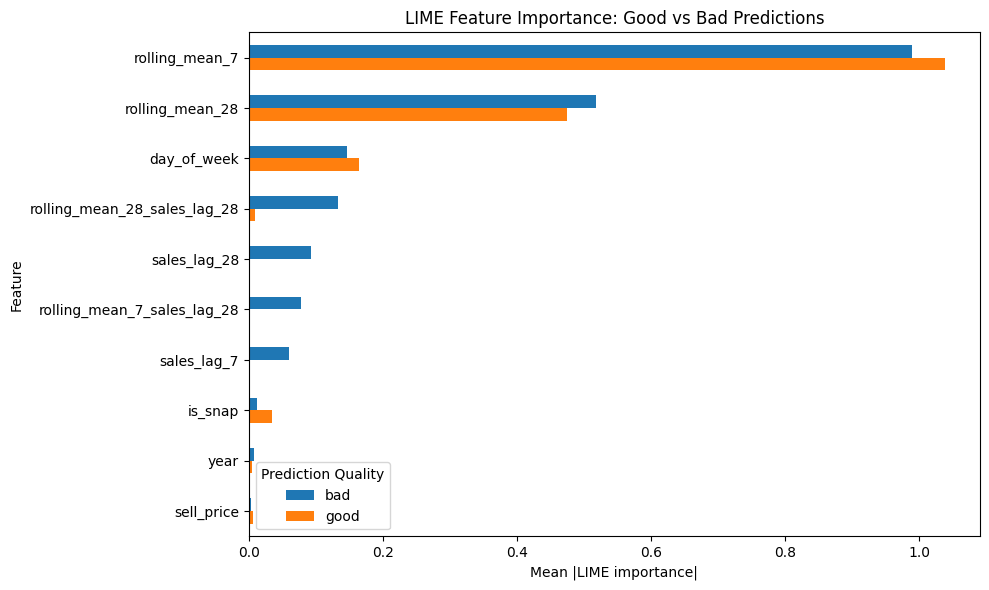

In [23]:
import matplotlib.pyplot as plt

lime_analysis['abs_importance'] = lime_analysis['importance'].abs()

plot_df = (
    lime_analysis
    .groupby(['feature', 'prediction_quality'])['abs_importance']
    .mean()
    .unstack(fill_value=0)
)

# Seleciona as features mais importantes considerando os dois grupos
top_features = (
    plot_df.mean(axis=1)
    .nlargest(10)
    .index
)

plot_df = plot_df.loc[top_features]

plot_df.plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Mean |LIME importance|')
plt.ylabel('Feature')
plt.title('LIME Feature Importance: Good vs Bad Predictions')
plt.legend(title='Prediction Quality')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

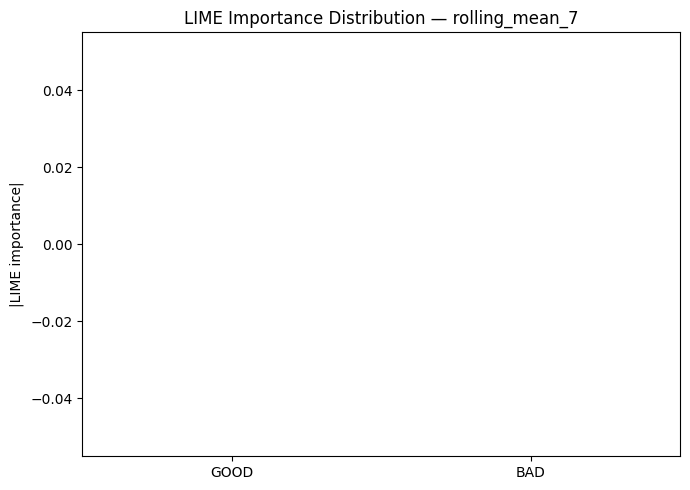

In [24]:
import matplotlib.pyplot as plt

feature = 'rolling_mean_7'

good = lime_analysis[
    (lime_analysis['feature'] == feature) &
    (lime_analysis['prediction_quality'] == 'GOOD')
]['abs_importance']

bad = lime_analysis[
    (lime_analysis['feature'] == feature) &
    (lime_analysis['prediction_quality'] == 'BAD')
]['abs_importance']

plt.figure(figsize=(7, 5))

plt.boxplot(
    [good, bad],
    tick_labels=['GOOD', 'BAD']
)

plt.ylabel('|LIME importance|')
plt.title(f'LIME Importance Distribution — {feature}')
plt.tight_layout()
plt.show()

In [ ]:
instance_id = 25407

example = (
    lime_analysis[
        lime_analysis['instance_id'] == instance_id
    ]
    .sort_values(
        'abs_importance',
        ascending=False
    )
    .head(10)
)

example[
    [
        'feature',
        'feature_value',
        'importance'
    ]
]

,feature,feature_value,importance
0,rolling_mean_7,0.8037058232415409,1.304956
1,day_of_week,7,-0.149838
2,week_of_year,17,0.041312
3,is_snap,0,0.033727
4,year,2016,-0.023557
5,day_of_month,29,-0.002765
6,store_id,TX_1,0.000000
7,state_id,TX,0.000000
8,item_id,FOODS_2_293,0.000000
9,dept_id,FOODS_2,0.000000


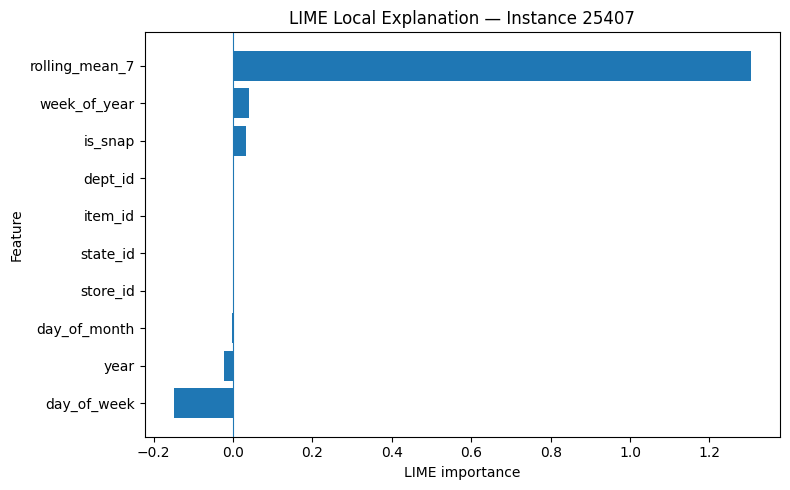

In [26]:
instance_id = 25407

plot_df = (
    lime_analysis[
        lime_analysis['instance_id'] == instance_id
    ]
    .sort_values(
        'importance',
        key=abs,
        ascending=False
    )
    .head(10)
    .sort_values('importance')
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.axvline(0, linewidth=0.8)

plt.xlabel('LIME importance')
plt.ylabel('Feature')
plt.title(f'LIME Local Explanation — Instance {instance_id}')

plt.tight_layout()
plt.show()

In [21]:
feature_error = (
    lime_analysis
    .groupby('feature')
    .apply(
        lambda x: x['abs_importance'].corr(
            x['absolute_error']
        ),
        include_groups=False
    )
    .sort_values()
)

feature_error

c:\Users\anderson\Downloads\GIT\demand-forecast-xai\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\anderson\Downloads\GIT\demand-forecast-xai\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


feature
is_snap                        -0.296852
day_of_month                   -0.127633
month                          -0.057983
week_of_year                   -0.057976
sell_price                     -0.041336
year                           -0.034534
day_of_week                    -0.026553
rolling_mean_7                  0.060704
sales_lag_28                    0.089065
sales_lag_7                     0.101272
rolling_mean_7_sales_lag_28     0.110646
rolling_mean_28                 0.111715
rolling_mean_28_sales_lag_28    0.197035
cat_id                               NaN
dept_id                              NaN
event_name_1                         NaN
event_name_2                         NaN
event_type_1                         NaN
event_type_2                         NaN
item_id                              NaN
state_id                             NaN
store_id                             NaN
dtype: float64

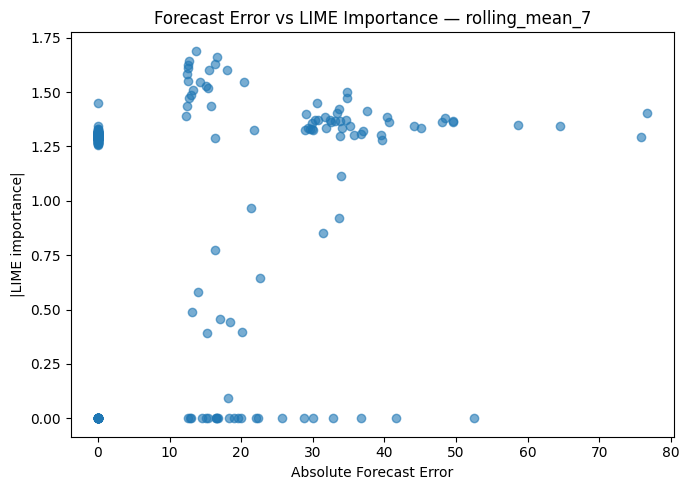

In [25]:
feature = 'rolling_mean_7'

plot_df = lime_analysis[
    lime_analysis['feature'] == feature
]

plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df['absolute_error'],
    plot_df['abs_importance'],
    alpha=0.6
)

plt.xlabel('Absolute Forecast Error')
plt.ylabel('|LIME importance|')
plt.title(
    f'Forecast Error vs LIME Importance — {feature}'
)

plt.tight_layout()
plt.show()